# R Analytics and Visualisation

The following visualisations were created using R and ggplot2 to identify operational patterns, complaint trends, and cost differences across NorthStar operational hubs.

In [1]:
%load_ext rpy2.ipython

In [2]:
%%R

install.packages("ggplot2")

library(ggplot2)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cran.rstudio.com/src/contrib/ggplot2_4.0.3.tar.gz'
Content type 'application/x-gzip' length 6327703 bytes (6.0 MB)
downloaded 6.0 MB


The downloaded source packages are in
	‘/tmp/Rtmp4grSdG/downloaded_packages’


In [4]:
%%R

deliveries <- read.csv("deliveries.csv")
orders <- read.csv("orders.csv")
complaints <- read.csv("complaints.csv")
drivers <- read.csv("drivers.csv")
hubs <- read.csv("hubs.csv")
incidents <- read.csv("incidents.csv")
vehicles <- read.csv("vehicles.csv")
customers <- read.csv("customers.csv")
app_events <- read.csv("app_events.csv")

cat("Datasets loaded successfully\n")

cat("Deliveries rows:", nrow(deliveries), "\n")
cat("Orders rows:", nrow(orders), "\n")
cat("Complaints rows:", nrow(complaints), "\n")
cat("Drivers rows:", nrow(drivers), "\n")
cat("Hubs rows:", nrow(hubs), "\n")
cat("Incidents rows:", nrow(incidents), "\n")
cat("Vehicles rows:", nrow(vehicles), "\n")
cat("Customers rows:", nrow(customers), "\n")
cat("App Events rows:", nrow(app_events), "\n")

Datasets loaded successfully
Deliveries rows: 950 
Orders rows: 1250 
Complaints rows: 320 
Drivers rows: 170 
Hubs rows: 8 
Incidents rows: 280 
Vehicles rows: 120 
Customers rows: 650 
App Events rows: 640 


## Visualisation 1: Delivery Status Distribution

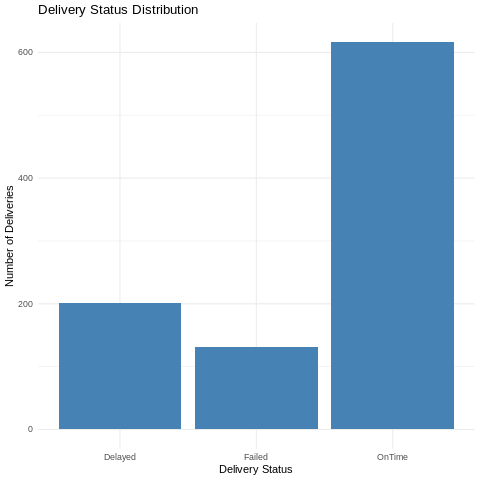

In [5]:
%%R

library(ggplot2)

ggplot(deliveries, aes(x = delivery_status)) +
  geom_bar(fill = "steelblue") +
  labs(
    title = "Delivery Status Distribution",
    x = "Delivery Status",
    y = "Number of Deliveries"
  ) +
  theme_minimal()

The visualisation shows that while most deliveries were completed successfully, delayed and failed deliveries still represent a significant operational issue for the organisation.

## Visualisation 2: Average Fuel or Charge Cost by Hub

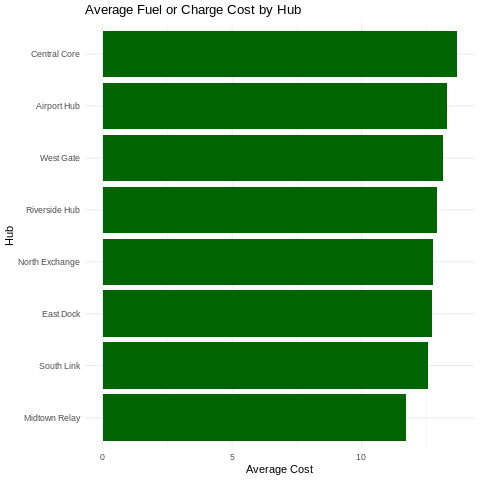

In [7]:
%%R

library(dplyr)
library(ggplot2)

hub_cost_analysis <- deliveries %>%
  left_join(hubs, by = "hub_id") %>%
  group_by(hub_name) %>%
  summarise(
    avg_cost = mean(fuel_or_charge_cost, na.rm = TRUE),
    total_deliveries = n()
  ) %>%
  arrange(desc(avg_cost))

ggplot(hub_cost_analysis,
       aes(x = reorder(hub_name, avg_cost),
           y = avg_cost)) +
  geom_bar(stat = "identity", fill = "darkgreen") +
  coord_flip() +
  labs(
    title = "Average Fuel or Charge Cost by Hub",
    x = "Hub",
    y = "Average Cost"
  ) +
  theme_minimal()

This visualisation compares average fuel or charging costs across NorthStar operational hubs to identify cost variation and possible hub-level efficiency issues.

## Visualisation 3: Complaint Severity Distribution

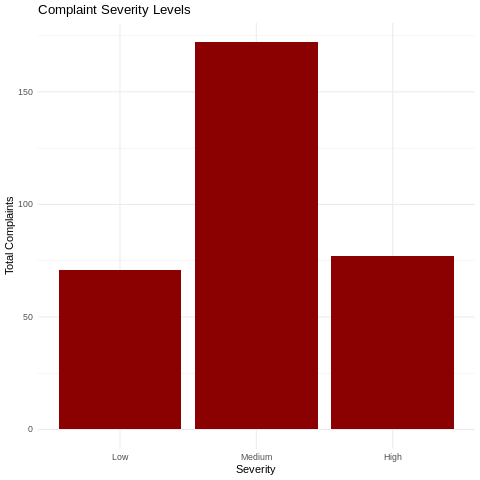

In [8]:
%%R

complaints$severity <- factor(
  complaints$severity,
  levels = c("Low", "Medium", "High")
)

ggplot(complaints, aes(x = severity)) +
  geom_bar(fill = "darkred") +
  labs(
    title = "Complaint Severity Levels",
    x = "Severity",
    y = "Total Complaints"
  ) +
  theme_minimal()

The majority of complaints were classified as medium severity, while high severity complaints may indicate major service failures requiring management attention.

## Visualisation 4: Driver manual route override analysis


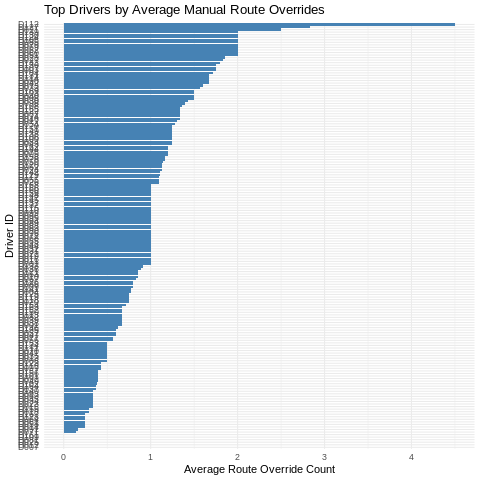

In [11]:
%%R

library(dplyr)
library(ggplot2)

route_override_analysis <- deliveries %>%
  group_by(driver_id) %>%
  summarise(
    total_deliveries = n(),
    total_route_overrides = sum(manual_route_override_count, na.rm = TRUE),
    avg_route_override = mean(manual_route_override_count, na.rm = TRUE)
  ) %>%
  filter(total_deliveries >= 2) %>%
  arrange(desc(total_route_overrides))

ggplot(route_override_analysis,
       aes(x = reorder(driver_id, avg_route_override),
           y = avg_route_override)) +
  geom_bar(stat = "identity", fill = "steelblue") +
  coord_flip() +
  labs(
    title = "Top Drivers by Average Manual Route Overrides",
    x = "Driver ID",
    y = "Average Route Override Count"
  ) +
  theme_minimal()

This visualisation examines driver manual route override behaviour to identify drivers with unusually high override activity during delivery operations.

## Visualisation 5: Average Customer Rating by Delivery Status

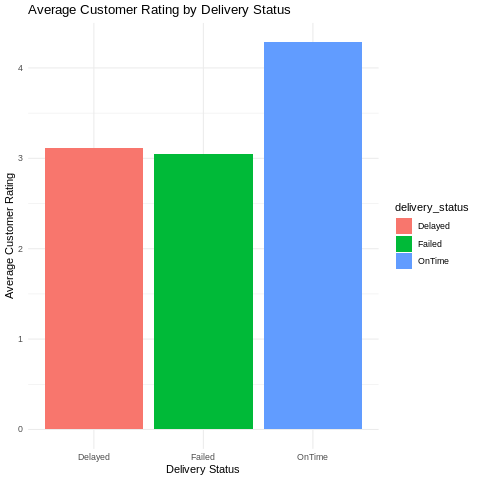

In [10]:
%%R

library(dplyr)
library(ggplot2)

rating_status_analysis <- deliveries %>%
  filter(!is.na(customer_rating_post_delivery)) %>%
  group_by(delivery_status) %>%
  summarise(
    avg_rating = mean(customer_rating_post_delivery, na.rm = TRUE),
    total_deliveries = n()
  ) %>%
  arrange(desc(avg_rating))

ggplot(rating_status_analysis,
       aes(x = delivery_status,
           y = avg_rating,
           fill = delivery_status)) +
  geom_bar(stat = "identity") +
  labs(
    title = "Average Customer Rating by Delivery Status",
    x = "Delivery Status",
    y = "Average Customer Rating"
  ) +
  theme_minimal()

This visualisation compares average customer ratings across delivery status categories to examine how operational performance affects customer satisfaction.

## Visualisation 6: Delayed Deliveries by Drop-off Zone

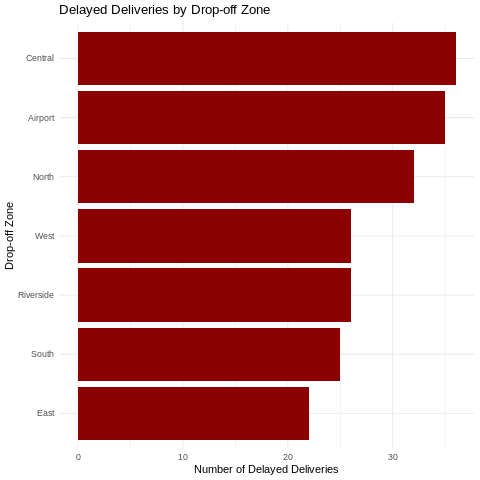

In [12]:
%%R

library(dplyr)
library(ggplot2)

delayed_zone_analysis <- deliveries %>%
  left_join(orders, by = "order_id") %>%
  filter(delivery_status == "Delayed") %>%
  mutate(
    cleaned_zone = case_when(
      toupper(dropoff_zone) %in% c("CENTRAL", "CTR") ~ "Central",
      toupper(dropoff_zone) == "AIRPORT" ~ "Airport",
      toupper(dropoff_zone) == "NORTH" ~ "North",
      toupper(dropoff_zone) == "SOUTH" ~ "South",
      toupper(dropoff_zone) == "EAST" ~ "East",
      toupper(dropoff_zone) == "WEST" ~ "West",
      toupper(dropoff_zone) == "RIVERSIDE" ~ "Riverside",
      TRUE ~ dropoff_zone
    )
  ) %>%
  group_by(cleaned_zone) %>%
  summarise(delayed_deliveries = n()) %>%
  arrange(desc(delayed_deliveries))

ggplot(delayed_zone_analysis,
       aes(x = reorder(cleaned_zone, delayed_deliveries),
           y = delayed_deliveries)) +
  geom_bar(stat = "identity", fill = "darkred") +
  coord_flip() +
  labs(
    title = "Delayed Deliveries by Drop-off Zone",
    x = "Drop-off Zone",
    y = "Number of Delayed Deliveries"
  ) +
  theme_minimal()

This visualisation identifies which operational drop-off zones experience the highest number of delayed deliveries across NorthStar’s service network.

## Visualisation 7: Delivery Status by Service Type

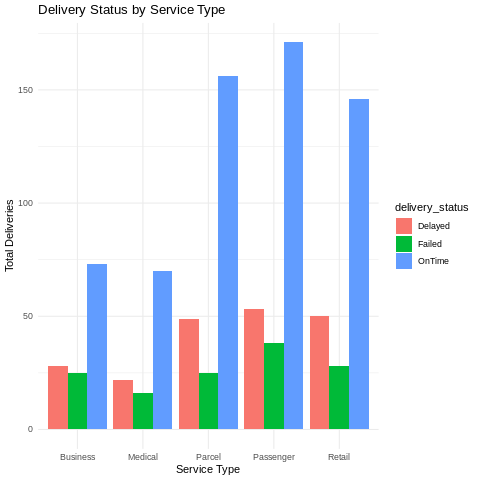

In [13]:
%%R

library(dplyr)
library(ggplot2)

service_status_analysis <- deliveries %>%
  left_join(orders, by = "order_id") %>%
  group_by(service_type, delivery_status) %>%
  summarise(total_deliveries = n(), .groups = "drop")

ggplot(service_status_analysis,
       aes(x = service_type,
           y = total_deliveries,
           fill = delivery_status)) +
  geom_bar(stat = "identity", position = "dodge") +
  labs(
    title = "Delivery Status by Service Type",
    x = "Service Type",
    y = "Total Deliveries"
  ) +
  theme_minimal()

This visualisation compares delivery outcomes across different service types to identify which services experience higher levels of delay or failure.

## Visualisation 8: Complaint Severity by Service Type

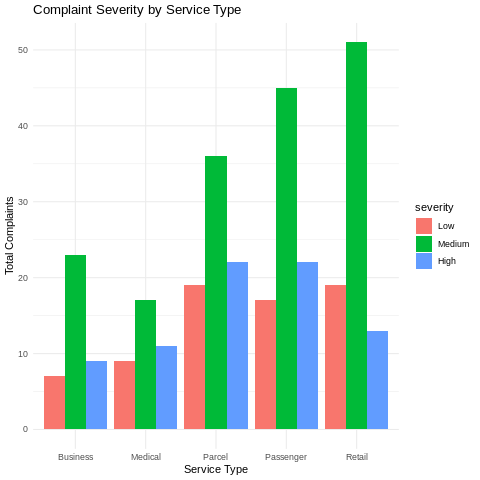

In [14]:
%%R

library(dplyr)
library(ggplot2)

complaint_service_analysis <- complaints %>%
  left_join(orders, by = "order_id") %>%
  group_by(service_type, severity) %>%
  summarise(
    total_complaints = n(),
    avg_compensation = mean(compensation_amount, na.rm = TRUE),
    .groups = "drop"
  )

ggplot(complaint_service_analysis,
       aes(x = service_type,
           y = total_complaints,
           fill = severity)) +
  geom_bar(stat = "identity", position = "dodge") +
  labs(
    title = "Complaint Severity by Service Type",
    x = "Service Type",
    y = "Total Complaints"
  ) +
  theme_minimal()

This visualisation analyses complaint severity across different NorthStar service types to identify which services generate higher customer dissatisfaction and operational risk.